# Adult Income Data Quality Diagnosis

This notebook performs a conservative quality diagnosis of the Adult Income dataset used in the Kaggle competition. The goal is to understand structure, missingness, extreme values, duplication, and semantic consistency before any cleaning rules are applied.

Key principles used throughout the notebook:
- preserve raw records in this notebook
- diagnose issues first, then propose cleaning rules
- use `Extra-file-from-UCI.txt` as the metadata reference
- keep `fnlwgt` as a profiled feature, not as an impossibility filter


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)


In [ ]:
def resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "data" / "adult-pmr3508").exists():
            return candidate
    raise FileNotFoundError("Could not find data/adult-pmr3508 from the current working directory.")


PROJECT_ROOT = resolve_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "adult-pmr3508"
TRAIN_PATH = DATA_DIR / "train_data.csv"
TEST_PATH = DATA_DIR / "test_data.csv"
EXTRA_PATH = DATA_DIR / "Extra-file-from-UCI.txt"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
uci_text = EXTRA_PATH.read_text()

feature_columns = [column for column in train_df.columns if column not in ["Id", "income"]]
categorical_features = train_df[feature_columns].select_dtypes(include="object").columns.tolist()
numeric_features = train_df[feature_columns].select_dtypes(include=np.number).columns.tolist()
combined_df = pd.concat(
    [
        train_df.assign(split="train"),
        test_df.assign(split="test", income=pd.NA), # type: ignore
    ],
    ignore_index=True,
    sort=False,
)

display_name_map = {
    column: column.replace(".", " ").replace("_", " ").title()
    for column in list(train_df.columns)
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
display(train_df.head())


Project root: /home/matheuscm/classifier-adults-dataset
Train shape: (32560, 16)
Test shape: (16280, 15)


/tmp/ipykernel_78457/3775265257.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train_df[feature_columns].select_dtypes(include="object").columns.tolist()


,Id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,16280,34,Private,204991,Some-college,10,Divorced,Exec-managerial,Own-child,White,Male,0,0,44,United-States,<=50K
1,16281,58,Local-gov,310085,10th,6,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
2,16282,25,Private,146117,Some-college,10,Never-married,Machine-op-inspct,Not-in-family,White,Male,0,0,42,United-States,<=50K
3,16283,24,Private,138938,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
4,16284,57,Self-emp-inc,258883,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,5178,0,60,Hungary,>50K


## Notebook Scope

This is a diagnosis plus proposal notebook. It does **not** export a cleaned dataset. Instead, it inspects raw files, summarizes the most important quality risks, and closes with candidate preparation rules for the next notebook or script.


In [4]:
NORMALIZED_UCI_NAME_MAP = {
    "education-num": "education.num",
    "marital-status": "marital.status",
    "capital-gain": "capital.gain",
    "capital-loss": "capital.loss",
    "hours-per-week": "hours.per.week",
    "native-country": "native.country",
}



def normalize_uci_name(name: str) -> str:
    normalized = name.strip().lower()
    return NORMALIZED_UCI_NAME_MAP.get(normalized, normalized)



def parse_uci_feature_metadata(text: str) -> pd.DataFrame:
    records = []
    for line in text.splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("|") or ":" not in stripped:
            continue
        name, description = stripped.split(":", 1)
        normalized_name = normalize_uci_name(name)
        if normalized_name not in set(feature_columns):
            continue
        description = description.strip()
        expected_type = "numeric" if description.lower().startswith("continuous") else "categorical"
        known_values = pd.NA if expected_type == "numeric" else description
        records.append(
            {
                "column": normalized_name,
                "uci_name": name.strip(),
                "expected_type": expected_type,
                "known_values_or_description": known_values,
                "uci_description": description,
            }
        )
    metadata_df = pd.DataFrame(records).drop_duplicates(subset=["column"])
    return metadata_df



def extract_uci_counts(text: str) -> dict:
    return {
        "uci_total_instances": int(re.search(r"\|\s*(\d+) instances", text).group(1)), # type: ignore
        "uci_train_instances": int(re.search(r"train=(\d+)", text).group(1)), # type: ignore
        "uci_test_instances": int(re.search(r"test=(\d+)", text).group(1)), # pyright: ignore[reportOptionalMemberAccess]
        "uci_without_unknown_total": int(re.search(r"\|\s*(\d+) if instances with unknown values are removed", text).group(1)),
        "uci_without_unknown_train": int(re.search(r"if instances with unknown values are removed \(train=(\d+)", text).group(1)),
        "uci_without_unknown_test": int(re.search(r"if instances with unknown values are removed \(train=\d+, test=(\d+)\)", text).group(1)),
    }



def question_mark_count(series: pd.Series) -> int:
    if not (pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series)):
        return 0
    return int(series.astype("string").str.strip().eq("?").sum())



def missing_like_summary(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    records = []
    for column in df.columns:
        actual_nulls = int(df[column].isna().sum())
        question_marks = question_mark_count(df[column])
        missing_like = actual_nulls + question_marks
        records.append(
            {
                "split": split_name,
                "column": column,
                "actual_nulls": actual_nulls,
                "question_marks": question_marks,
                "missing_like_count": missing_like,
                "missing_like_pct": missing_like / len(df),
            }
        )
    return pd.DataFrame(records)



def rare_category_summary(train_frame: pd.DataFrame, test_frame: pd.DataFrame, column: str, rare_threshold: int = 20) -> pd.DataFrame:
    train_counts = train_frame[column].astype("string").str.strip().value_counts(dropna=False)
    test_counts = test_frame[column].astype("string").str.strip().value_counts(dropna=False)
    levels = sorted(set(train_counts.index).union(set(test_counts.index)))
    records = []
    for level in levels:
        train_count = int(train_counts.get(level, 0))
        test_count = int(test_counts.get(level, 0))
        records.append(
            {
                "column": column,
                "level": level,
                "train_count": train_count,
                "test_count": test_count,
                "rare_in_train": train_count < rare_threshold,
                "train_only": train_count > 0 and test_count == 0,
                "test_only": test_count > 0 and train_count == 0,
            }
        )
    return pd.DataFrame(records)



def format_pct(value: float) -> str:
    return f"{value:.2%}"


uci_metadata_df = parse_uci_feature_metadata(uci_text)
uci_counts = extract_uci_counts(uci_text)


## Metadata and Data Dictionary

The UCI companion text provides the original variable descriptions and the extraction notes. The table below converts that text into a working data dictionary aligned with the actual CSV column names used in this repository.


In [5]:
observed_columns = list(train_df.columns)
data_dictionary_records = []

for column in observed_columns:
    metadata_match = uci_metadata_df.loc[uci_metadata_df["column"] == column]
    if column == "Id":
        expected_type = "identifier"
        description = "Competition row identifier added by Kaggle. Not part of the original UCI field list."
        known_values = pd.NA
    elif column == "income":
        expected_type = "target"
        description = "Binary income label from UCI: >50K or <=50K."
        known_values = ">50K, <=50K"
    elif not metadata_match.empty:
        expected_type = metadata_match.iloc[0]["expected_type"]
        description = metadata_match.iloc[0]["uci_description"]
        known_values = metadata_match.iloc[0]["known_values_or_description"]
    else:
        expected_type = "unknown"
        description = "No metadata entry found in Extra-file-from-UCI.txt."
        known_values = pd.NA

    data_dictionary_records.append(
        {
            "column": column,
            "display_name": display_name_map[column],
            "expected_type": expected_type,
            "train_dtype": str(train_df[column].dtype),
            "present_in_test": column in test_df.columns,
            "known_values_or_description": known_values,
            "notes": description,
        }
    )

data_dictionary_df = pd.DataFrame(data_dictionary_records)
display(data_dictionary_df)
display(Markdown("**UCI extraction rule noted in the source text:** `((AAGE>16) && (AGI>100) && (AFNLWGT>1) && (HRSWK>0))`"))


,column,display_name,expected_type,train_dtype,present_in_test,known_values_or_description,notes
0,Id,Id,identifier,int64,True,NaN,Competition row identifier added by Kaggle. Not part of the original UCI field list.
1,age,Age,numeric,int64,True,NaN,continuous.
2,workclass,Workclass,categorical,str,True,"Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.","Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked."
3,fnlwgt,Fnlwgt,numeric,int64,True,NaN,continuous.
4,education,Education,categorical,str,True,"Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10...","Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10..."
5,education.num,Education Num,numeric,int64,True,NaN,continuous.
6,marital.status,Marital Status,categorical,str,True,"Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.","Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse."
7,occupation,Occupation,categorical,str,True,"Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-ins...","Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-ins..."
8,relationship,Relationship,categorical,str,True,"Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.","Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried."
9,race,Race,categorical,str,True,"White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.","White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black."


**UCI extraction rule noted in the source text:** `((AAGE>16) && (AGI>100) && (AFNLWGT>1) && (HRSWK>0))`

## Structural Audit

This section checks the basic integrity of the files: row counts, schema parity, identifier behavior, and whether the observed files line up with the UCI metadata.


In [6]:
structural_audit_df = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": len(train_df),
            "columns": train_df.shape[1],
            "id_unique": train_df["Id"].is_unique,
            "target_present": "income" in train_df.columns,
        },
        {
            "split": "test",
            "rows": len(test_df),
            "columns": test_df.shape[1],
            "id_unique": test_df["Id"].is_unique,
            "target_present": "income" in test_df.columns,
        },
    ]
)
display(structural_audit_df)

schema_parity_df = pd.DataFrame(
    {
        "train_only_columns": [sorted(set(train_df.columns) - set(test_df.columns))],
        "test_only_columns": [sorted(set(test_df.columns) - set(train_df.columns))],
        "feature_schema_matches": [sorted(feature_columns) == sorted(test_df.columns.drop("Id").tolist())],
    }
)
display(schema_parity_df)

uci_count_comparison_df = pd.DataFrame(
    [
        {"metric": "train rows", "uci_reference": uci_counts["uci_train_instances"], "observed": len(train_df), "difference": len(train_df) - uci_counts["uci_train_instances"]},
        {"metric": "test rows", "uci_reference": uci_counts["uci_test_instances"], "observed": len(test_df), "difference": len(test_df) - uci_counts["uci_test_instances"]},
        {"metric": "total rows", "uci_reference": uci_counts["uci_total_instances"], "observed": len(train_df) + len(test_df), "difference": len(train_df) + len(test_df) - uci_counts["uci_total_instances"]},
    ]
)
display(uci_count_comparison_df)

extraction_rule_check_df = pd.DataFrame(
    [
        {"rule": "age > 16", "observed_min": int(train_df["age"].min()), "passes": bool(train_df["age"].min() > 16)},
        {"rule": "fnlwgt > 1", "observed_min": int(train_df["fnlwgt"].min()), "passes": bool(train_df["fnlwgt"].min() > 1)},
        {"rule": "hours.per.week > 0", "observed_min": int(train_df["hours.per.week"].min()), "passes": bool(train_df["hours.per.week"].min() > 0)},
    ]
)
display(extraction_rule_check_df)


,split,rows,columns,id_unique,target_present
0,train,32560,16,True,True
1,test,16280,15,True,False


,train_only_columns,test_only_columns,feature_schema_matches
0,[income],[],True


,metric,uci_reference,observed,difference
0,train rows,32561,32560,-1
1,test rows,16281,16280,-1
2,total rows,48842,48840,-2


,rule,observed_min,passes
0,age > 16,17,True
1,fnlwgt > 1,12285,True
2,hours.per.week > 0,1,True


## Missing-Data Audit

The Adult dataset uses both explicit missing values and the sentinel value `?`. For quality diagnosis, both are treated as missing-like signals.


In [7]:
missing_like_df = pd.concat(
    [missing_like_summary(train_df, "train"), missing_like_summary(test_df, "test")],
    ignore_index=True,
)
missing_like_issues_df = missing_like_df.loc[missing_like_df["missing_like_count"] > 0].copy()
missing_like_issues_df["missing_like_pct"] = missing_like_issues_df["missing_like_pct"].map(format_pct)
display(missing_like_issues_df.sort_values(["split", "missing_like_count"], ascending=[True, False]))


,split,column,actual_nulls,question_marks,missing_like_count,missing_like_pct
23,test,occupation,0,966,966,5.93%
18,test,workclass,0,963,963,5.92%
30,test,native.country,0,274,274,1.68%
7,train,occupation,0,1843,1843,5.66%
2,train,workclass,0,1836,1836,5.64%
14,train,native.country,0,583,583,1.79%


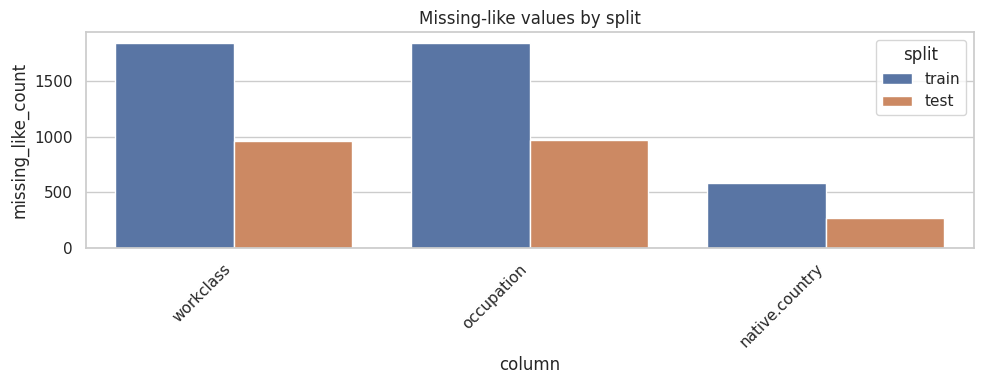

In [8]:
plot_missing_like_df = missing_like_df.loc[missing_like_df["missing_like_count"] > 0].copy()
plt.figure(figsize=(10, 4))
sns.barplot(data=plot_missing_like_df, x="column", y="missing_like_count", hue="split")
plt.title("Missing-like values by split")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Categorical Audit

This section profiles category cardinality, rare levels, and train/test category mismatches. The goal is to detect unstable categories before encoding decisions are made.


In [9]:
rare_threshold = 20
categorical_summary_records = []
category_mismatch_frames = []
rare_category_frames = []

for column in categorical_features:
    category_summary = rare_category_summary(train_df, test_df, column, rare_threshold=rare_threshold)
    category_mismatch_frames.append(category_summary.loc[category_summary["train_only"] | category_summary["test_only"]])
    rare_category_frames.append(category_summary.loc[(category_summary["rare_in_train"]) & (category_summary["train_count"] > 0) & (category_summary["level"] != "?")])
    train_value_counts = train_df[column].astype("string").str.strip().value_counts(dropna=False)
    categorical_summary_records.append(
        {
            "column": column,
            "train_unique_levels": train_df[column].astype("string").str.strip().nunique(dropna=True),
            "test_unique_levels": test_df[column].astype("string").str.strip().nunique(dropna=True),
            "missing_like_in_train": question_mark_count(train_df[column]),
            "missing_like_in_test": question_mark_count(test_df[column]),
            "rare_levels_in_train_lt_20": int(((train_value_counts < rare_threshold) & (train_value_counts.index != "?")).sum()),
        }
    )

categorical_summary_df = pd.DataFrame(categorical_summary_records)
category_mismatch_df = pd.concat(category_mismatch_frames, ignore_index=True).sort_values(["column", "level"])
rare_categories_df = pd.concat(rare_category_frames, ignore_index=True).sort_values(["column", "train_count", "level"])

display(categorical_summary_df)
display(category_mismatch_df)
display(rare_categories_df)


,column,train_unique_levels,test_unique_levels,missing_like_in_train,missing_like_in_test,rare_levels_in_train_lt_20
0,workclass,9,9,1836,963,2
1,education,16,16,0,0,0
2,marital.status,7,7,0,0,0
3,occupation,15,15,1843,966,1
4,relationship,6,6,0,0,0
5,race,5,5,0,0,0
6,sex,2,2,0,0,0
7,native.country,42,41,583,274,10


,column,level,train_count,test_count,rare_in_train,train_only,test_only
0,native.country,Holand-Netherlands,1,0,True,True,False


,column,level,train_count,test_count,rare_in_train,train_only,test_only
4,native.country,Holand-Netherlands,1,0,True,True,False
9,native.country,Scotland,12,9,True,False,False
5,native.country,Honduras,13,7,True,False,False
6,native.country,Hungary,13,6,True,False,False
8,native.country,Outlying-US(Guam-USVI-etc),14,9,True,False,False
12,native.country,Yugoslavia,16,7,True,False,False
7,native.country,Laos,18,5,True,False,False
10,native.country,Thailand,18,12,True,False,False
3,native.country,Cambodia,19,9,True,False,False
11,native.country,Trinadad&Tobago,19,8,True,False,False


In [10]:
for column in categorical_features:
    print(f"Top levels for {column}")
    display(train_df[column].astype("string").str.strip().value_counts(dropna=False).head(10).rename("train_count").to_frame())


Top levels for workclass


,train_count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1297
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


Top levels for education


,train_count
education,
HS-grad,10501
Some-college,7291
Bachelors,5354
Masters,1723
Assoc-voc,1382
11th,1175
Assoc-acdm,1067
10th,933
7th-8th,646


Top levels for marital.status


...

,train_count
race,
White,27815
Black,3124
Asian-Pac-Islander,1039
Amer-Indian-Eskimo,311
Other,271


Top levels for sex


,train_count
sex,
Male,21789
Female,10771


Top levels for native.country


,train_count
native.country,
United-States,29169
Mexico,643
?,583
Philippines,198
Germany,137
Canada,121
Puerto-Rico,114
El-Salvador,106
India,100


## Numeric Audit

Numeric profiling focuses on ranges, percentiles, and skew. `capital.gain` and `capital.loss` are expected to be sparse and right-skewed, so they are inspected both on their raw scale and on a `log1p` scale.


In [11]:
numeric_summary_df = (
    train_df[numeric_features]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .T
    .rename(columns={"1%": "p01", "5%": "p05", "25%": "p25", "50%": "p50", "75%": "p75", "95%": "p95", "99%": "p99"})
)
display(numeric_summary_df)

zero_inflation_df = pd.DataFrame(
    [
        {
            "column": column,
            "zero_count": int((train_df[column] == 0).sum()),
            "zero_pct": format_pct((train_df[column] == 0).mean()),
        }
        for column in numeric_features
    ]
).sort_values(["zero_count", "column"], ascending=[False, True])
display(zero_inflation_df)

numeric_split_comparison_df = (
    combined_df.groupby("split")[numeric_features]
    .agg(["min", "median", "max"])
    .transpose()
)
display(numeric_split_comparison_df)


,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
age,32560.0,38.581634,13.640642,17.0,17.00,19.0,28.0,37.0,48.0,63.0,74.0,90.0
fnlwgt,32560.0,189781.814373,105549.764924,12285.0,27185.77,39458.6,117831.5,178363.0,237054.5,379686.3,510072.0,1484705.0
education.num,32560.0,10.080590,2.572709,1.0,3.00,5.0,9.0,10.0,12.0,14.0,16.0,16.0
capital.gain,32560.0,1077.615172,7385.402999,0.0,0.00,0.0,0.0,0.0,0.0,5013.0,15024.0,99999.0
capital.loss,32560.0,87.306511,402.966116,0.0,0.00,0.0,0.0,0.0,0.0,0.0,1980.0,4356.0
hours.per.week,32560.0,40.437469,12.347618,1.0,8.00,18.0,40.0,40.0,45.0,60.0,80.0,99.0


,column,zero_count,zero_pct
4,capital.loss,31041,95.33%
3,capital.gain,29849,91.67%
0,age,0,0.00%
2,education.num,0,0.00%
1,fnlwgt,0,0.00%
5,hours.per.week,0,0.00%


split                       test      train
age            min          17.0       17.0
               median       37.0       37.0
               max          90.0       90.0
fnlwgt         min       13492.0    12285.0
               median   177829.5   178363.0
               max     1490400.0  1484705.0
education.num  min           1.0        1.0
               median       10.0       10.0
               max          16.0       16.0
capital.gain   min           0.0        0.0
               median        0.0        0.0
               max       99999.0    99999.0
capital.loss   min           0.0        0.0
               median        0.0        0.0
               max        3770.0     4356.0
hours.per.week min           1.0        1.0
               median       40.0       40.0
               max          99.0       99.0

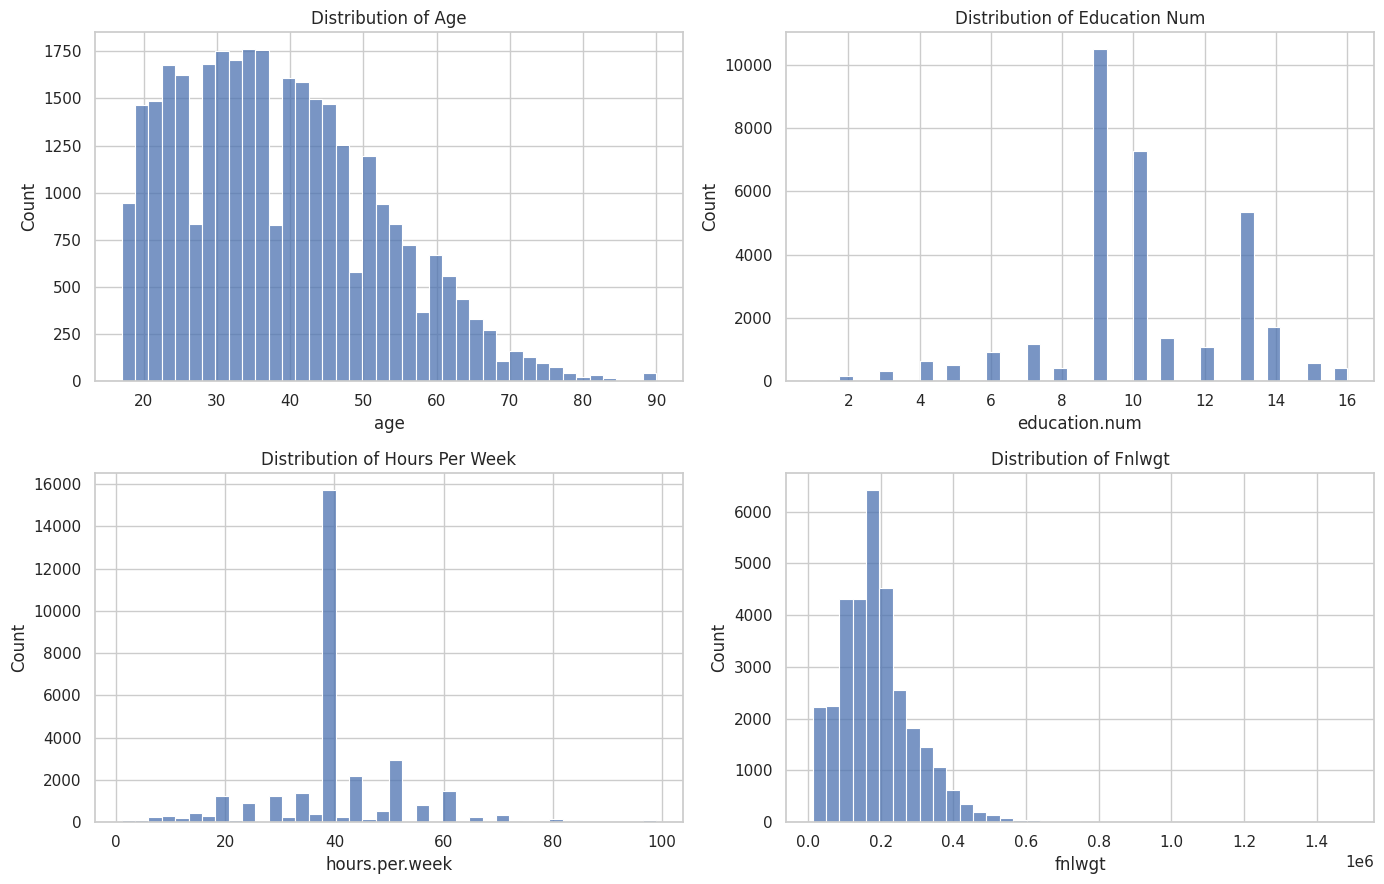

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, column in zip(axes.flatten(), ["age", "education.num", "hours.per.week", "fnlwgt"]):
    sns.histplot(train_df[column], bins=40, ax=ax)
    ax.set_title(f"Distribution of {display_name_map[column]}")
plt.tight_layout()
plt.show()


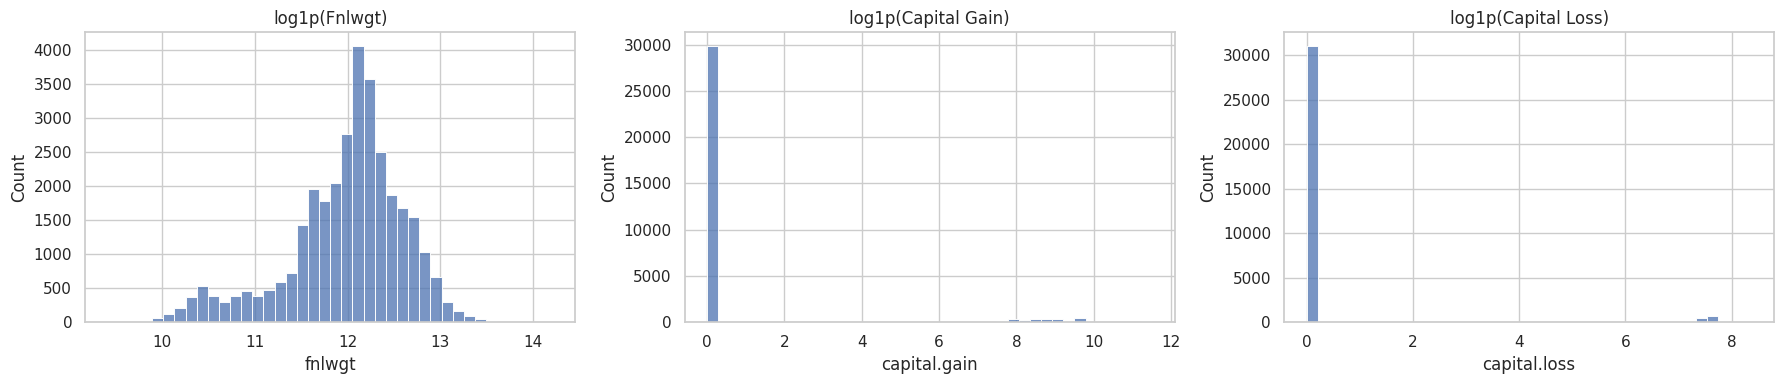

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, column in zip(axes, ["fnlwgt", "capital.gain", "capital.loss"]):
    sns.histplot(np.log1p(train_df[column]), bins=40, ax=ax)
    ax.set_title(f"log1p({display_name_map[column]})")
plt.tight_layout()
plt.show()


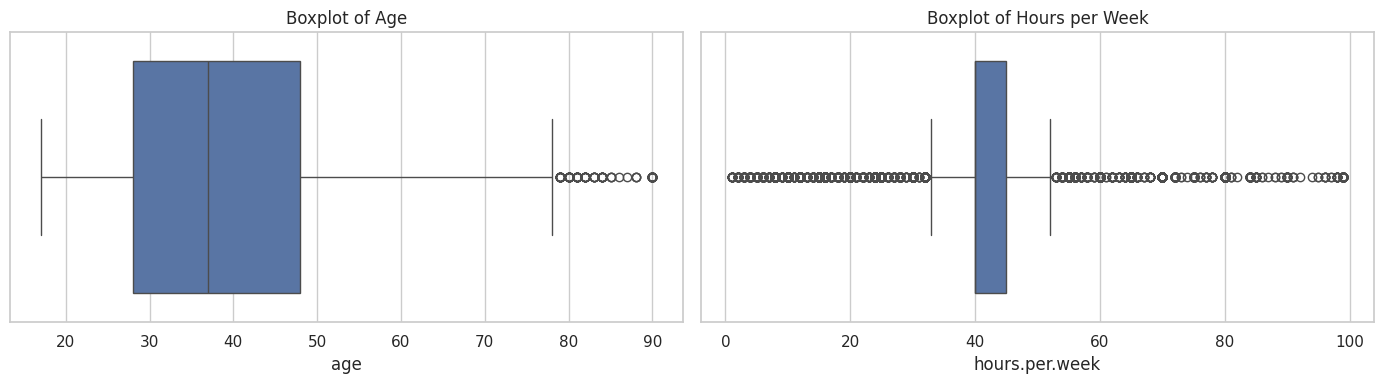

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=train_df["age"], ax=axes[0])
axes[0].set_title("Boxplot of Age")
sns.boxplot(x=train_df["hours.per.week"], ax=axes[1])
axes[1].set_title("Boxplot of Hours per Week")
plt.tight_layout()
plt.show()


## Semantic Consistency Audit

This section checks relationships that should remain coherent across fields. Suspicious records are **flagged for review**, not automatically removed.


In [15]:
education_mapping_df = (
    combined_df.groupby("education", dropna=False)["education.num"]
    .agg(["nunique", lambda values: sorted(pd.Series(values).dropna().unique().tolist())])
    .reset_index()
    .rename(columns={"nunique": "education_num_cardinality", "<lambda_0>": "education_num_values"})
    .sort_values("education")
)
display(education_mapping_df)

education_inconsistencies_df = education_mapping_df.loc[education_mapping_df["education_num_cardinality"] > 1]
display(education_inconsistencies_df)


,education,education_num_cardinality,education_num_values
0,10th,1,[6]
1,11th,1,[7]
2,12th,1,[8]
3,1st-4th,1,[2]
4,5th-6th,1,[3]
5,7th-8th,1,[4]
6,9th,1,[5]
7,Assoc-acdm,1,[12]
8,Assoc-voc,1,[11]
9,Bachelors,1,[13]


,education,education_num_cardinality,education_num_values


In [16]:
exact_duplicate_mask = train_df.duplicated(subset=[column for column in train_df.columns if column != "Id"], keep=False)
exact_duplicate_count = int(train_df.duplicated(subset=[column for column in train_df.columns if column != "Id"]).sum())
exact_duplicate_examples_df = train_df.loc[exact_duplicate_mask].sort_values(["age", "workclass", "education", "occupation", "income", "Id"]).head(10)

feature_only_columns = [column for column in train_df.columns if column not in ["Id", "income"]]
conflict_groups_df = (
    train_df.groupby(feature_only_columns, dropna=False)["income"]
    .nunique()
    .reset_index(name="income_label_cardinality")
    .query("income_label_cardinality > 1")
)
conflicting_rows_df = train_df.merge(conflict_groups_df[feature_only_columns], on=feature_only_columns, how="inner")

print(f"Exact duplicate rows in train, excluding Id: {exact_duplicate_count}")
display(exact_duplicate_examples_df)
print(f"Conflicting feature groups in train: {len(conflict_groups_df)}")
display(conflicting_rows_df.sort_values(feature_only_columns + ["income", "Id"]))


Exact duplicate rows in train, excluding Id: 24


,Id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
22252,38532,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
28739,45019,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
16762,33042,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
30887,47167,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
27881,44161,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
31449,47729,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
11999,28279,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
15454,31734,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
2294,18574,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
11171,27451,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K


Conflicting feature groups in train: 1


,Id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,44434,39,Private,138192,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
1,48266,39,Private,138192,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K


In [17]:
hours_review_threshold = 80
hours_extremes_df = pd.DataFrame(
    [
        {"threshold": ">= 60", "count": int((train_df["hours.per.week"] >= 60).sum()), "pct_of_train": format_pct((train_df["hours.per.week"] >= 60).mean())},
        {"threshold": ">= 80", "count": int((train_df["hours.per.week"] >= 80).sum()), "pct_of_train": format_pct((train_df["hours.per.week"] >= 80).mean())},
        {"threshold": ">= 90", "count": int((train_df["hours.per.week"] >= 90).sum()), "pct_of_train": format_pct((train_df["hours.per.week"] >= 90).mean())},
    ]
)
display(hours_extremes_df)

display(
    train_df.loc[
        train_df["hours.per.week"] >= hours_review_threshold,
        ["Id", "age", "workclass", "occupation", "hours.per.week", "income"],
    ].head(15)
)


,threshold,count,pct_of_train
0,>= 60,2585,7.94%
1,>= 80,341,1.05%
2,>= 90,139,0.43%


,Id,age,workclass,occupation,hours.per.week,income
17,16297,29,Private,Transport-moving,80,<=50K
23,16303,26,Private,Adm-clerical,80,>50K
44,16324,51,Self-emp-not-inc,Other-service,99,<=50K
57,16337,49,Self-emp-not-inc,Prof-specialty,85,>50K
219,16499,27,Self-emp-not-inc,Farming-fishing,80,<=50K
247,16527,58,Private,Prof-specialty,99,<=50K
275,16555,27,Local-gov,Exec-managerial,80,>50K
319,16599,42,Self-emp-inc,Exec-managerial,90,>50K
543,16823,25,Private,Other-service,99,<=50K
626,16906,51,Local-gov,Prof-specialty,80,>50K


In [18]:
plausibility_checks = {
    "married_under_18": (combined_df["age"] < 18) & combined_df["marital.status"].astype("string").str.startswith("Married", na=False),
    "spouse_role_under_18": (combined_df["age"] < 18) & combined_df["relationship"].isin(["Husband", "Wife"]),
    "never_worked_with_known_occupation": (combined_df["workclass"] == "Never-worked") & (combined_df["occupation"].astype("string").str.strip() != "?"),
    "own_child_and_married": (combined_df["relationship"] == "Own-child") & combined_df["marital.status"].astype("string").str.startswith("Married", na=False),
}

plausibility_summary_df = pd.DataFrame(
    [
        {
            "check": check_name,
            "flagged_rows": int(mask.sum()),
            "pct_of_all_rows": format_pct(mask.mean()),
        }
        for check_name, mask in plausibility_checks.items()
    ]
)
display(plausibility_summary_df)

for check_name, mask in plausibility_checks.items():
    print(check_name)
    display(
        combined_df.loc[
            mask,
            ["split", "Id", "age", "marital.status", "relationship", "workclass", "occupation", "hours.per.week", "income"],
        ].head(10)
    )


,check,flagged_rows,pct_of_all_rows
0,married_under_18,3,0.01%
1,spouse_role_under_18,1,0.00%
2,never_worked_with_known_occupation,0,0.00%
3,own_child_and_married,205,0.42%


married_under_18


,split,Id,age,marital.status,relationship,workclass,occupation,hours.per.week,income
2943,train,19223,17,Married-civ-spouse,Husband,Private,Other-service,40,<=50K
8709,train,24989,17,Married-civ-spouse,Own-child,Private,Sales,30,<=50K
44942,test,12382,17,Married-spouse-absent,Other-relative,Private,Other-service,40,<NA>


spouse_role_under_18


,split,Id,age,marital.status,relationship,workclass,occupation,hours.per.week,income
2943,train,19223,17,Married-civ-spouse,Husband,Private,Other-service,40,<=50K


never_worked_with_known_occupation


,split,Id,age,marital.status,relationship,workclass,occupation,hours.per.week,income


own_child_and_married


,split,Id,age,marital.status,relationship,workclass,occupation,hours.per.week,income
26,train,16306,35,Married-spouse-absent,Own-child,Private,Sales,36,<=50K
192,train,16472,41,Married-civ-spouse,Own-child,Private,Exec-managerial,40,>50K
729,train,17009,25,Married-civ-spouse,Own-child,Private,Craft-repair,40,<=50K
774,train,17054,36,Married-civ-spouse,Own-child,Local-gov,Prof-specialty,40,<=50K
1176,train,17456,20,Married-spouse-absent,Own-child,?,?,40,<=50K
1496,train,17776,27,Married-civ-spouse,Own-child,Private,Other-service,40,<=50K
2220,train,18500,19,Married-spouse-absent,Own-child,Private,Sales,40,<=50K
2232,train,18512,28,Married-spouse-absent,Own-child,Private,Other-service,35,<=50K
2339,train,18619,18,Married-spouse-absent,Own-child,Private,Other-service,40,<=50K
2425,train,18705,23,Married-civ-spouse,Own-child,?,?,30,<=50K


## Proposed Preparation Rules

These are candidate rules for the next cleaning notebook or script. They intentionally separate evidence from action so the next step can stay reviewable.


In [19]:
missing_like_lookup = missing_like_df.set_index(["split", "column"])
proposal_df = pd.DataFrame(
    [
        {
            "issue": "Sentinel '?' values in categorical columns",
            "evidence": (
                f"Train counts: workclass={int(missing_like_lookup.loc[('train', 'workclass'), 'question_marks'])}, "
                f"occupation={int(missing_like_lookup.loc[('train', 'occupation'), 'question_marks'])}, "
                f"native.country={int(missing_like_lookup.loc[('train', 'native.country'), 'question_marks'])}."
            ),
            "candidate_treatment": "Map '?' to missing, then choose imputation or explicit 'Unknown' handling in the next cleaning step.",
            "leakage_risk": "Low",
            "apply_in_next_step": "Yes",
        },
        {
            "issue": "Exact duplicate rows in train excluding Id",
            "evidence": f"Detected {exact_duplicate_count} duplicate rows when Id is excluded.",
            "candidate_treatment": "Review and likely deduplicate exact copies before modeling, while preserving an audit trail.",
            "leakage_risk": "Low",
            "apply_in_next_step": "Yes",
        },
        {
            "issue": "Conflicting duplicate feature groups",
            "evidence": f"Detected {len(conflict_groups_df)} feature group with more than one income label.",
            "candidate_treatment": "Quarantine or tag conflicting rows for sensitivity analysis instead of dropping them silently.",
            "leakage_risk": "Low",
            "apply_in_next_step": "Yes",
        },
        {
            "issue": "Rare categorical levels",
            "evidence": "Very small support exists in categories such as Holand-Netherlands and several low-frequency native-country values.",
            "candidate_treatment": "Consider frequency-based grouping for unstable categories after documenting the grouping rule.",
            "leakage_risk": "Medium if thresholds are tuned on target behavior",
            "apply_in_next_step": "Yes",
        },
        {
            "issue": "Extreme hours per week",
            "evidence": f"Maximum hours.per.week is {int(train_df['hours.per.week'].max())}, with {int((train_df['hours.per.week'] >= 80).sum())} rows at or above 80 hours.",
            "candidate_treatment": "Create review flags or capped variants for modeling, but keep the raw field unchanged in the first cleaning pass.",
            "leakage_risk": "Low",
            "apply_in_next_step": "Yes",
        },
        {
            "issue": "Strong zero inflation in capital fields",
            "evidence": (
                f"capital.gain is zero in {format_pct((train_df['capital.gain'] == 0).mean())} of train rows and "
                f"capital.loss is zero in {format_pct((train_df['capital.loss'] == 0).mean())}."
            ),
            "candidate_treatment": "Consider binary indicator features plus transformed positive values rather than treating the zeros as outliers.",
            "leakage_risk": "Low",
            "apply_in_next_step": "Yes",
        },
        {
            "issue": "fnlwgt interpretation",
            "evidence": "UCI describes fnlwgt as a survey weighting field, not a direct validity check.",
            "candidate_treatment": "Keep fnlwgt available for modeling experiments, but do not use it as an impossibility filter.",
            "leakage_risk": "Low",
            "apply_in_next_step": "Yes",
        },
    ]
)
display(proposal_df)


,issue,evidence,candidate_treatment,leakage_risk,apply_in_next_step
0,Sentinel '?' values in categorical columns,"Train counts: workclass=1836, occupation=1843, native.country=583.","Map '?' to missing, then choose imputation or explicit 'Unknown' handling in the next cleaning step.",Low,Yes
1,Exact duplicate rows in train excluding Id,Detected 24 duplicate rows when Id is excluded.,"Review and likely deduplicate exact copies before modeling, while preserving an audit trail.",Low,Yes
2,Conflicting duplicate feature groups,Detected 1 feature group with more than one income label.,Quarantine or tag conflicting rows for sensitivity analysis instead of dropping them silently.,Low,Yes
3,Rare categorical levels,Very small support exists in categories such as Holand-Netherlands and several low-frequency native-country values.,Consider frequency-based grouping for unstable categories after documenting the grouping rule.,Medium if thresholds are tuned on target behavior,Yes
4,Extreme hours per week,"Maximum hours.per.week is 99, with 341 rows at or above 80 hours.","Create review flags or capped variants for modeling, but keep the raw field unchanged in the first cleaning pass.",Low,Yes
5,Strong zero inflation in capital fields,capital.gain is zero in 91.67% of train rows and capital.loss is zero in 95.33%.,Consider binary indicator features plus transformed positive values rather than treating the zeros as outliers.,Low,Yes
6,fnlwgt interpretation,"UCI describes fnlwgt as a survey weighting field, not a direct validity check.","Keep fnlwgt available for modeling experiments, but do not use it as an impossibility filter.",Low,Yes


## Headline Findings

- The train file has 32,560 rows, which is one row fewer than the 32,561 train instances described in the UCI companion text.
- Missing-like values are concentrated in `workclass`, `occupation`, and `native.country` through the sentinel value `?`.
- The training data contains exact duplicates and one conflicting feature group with different target labels.
- `hours.per.week` reaches 99, which is extreme but still plausible enough to flag for review instead of auto-removal.
- `capital.gain` and `capital.loss` are highly zero-inflated and should be modeled with that structure in mind.
- `fnlwgt` should be documented and profiled, but not used as a rule for impossible-value filtering.
